In [2]:
import pandas as pd

In [3]:
import os
os.listdir(".")

['.config', 'Concrete_Data.xls', 'Concrete_Readme.txt', 'sample_data']

In [26]:
df = pd.read_excel("Concrete_Data.xls")

In [5]:
df.shape

(1030, 9)

In [6]:
df.head()

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


In [27]:
col_rename = {'Cement (component 1)(kg in a m^3 mixture)':'cement',
'Blast Furnace Slag (component 2)(kg in a m^3 mixture)':'blast_furnace',
'Fly Ash (component 3)(kg in a m^3 mixture)':'fly_ash',
'Water  (component 4)(kg in a m^3 mixture)':'water',
'Superplasticizer (component 5)(kg in a m^3 mixture)':'superplasticizer',
'Coarse Aggregate  (component 6)(kg in a m^3 mixture)':'coarse_aggregate',
'Fine Aggregate (component 7)(kg in a m^3 mixture)':'fine_aggregate',
'Age (day)':'age',
'Concrete compressive strength(MPa, megapascals) ':'strength'}

df.rename(columns=col_rename,inplace=True)

In [11]:
df.columns

Index(['cement', 'blast_furnace', 'fly_ash', 'water', 'superplasticizer',
       'coarse_aggregate', 'fine_aggregate', 'age', 'strength'],
      dtype='object')

In [12]:
df.head()

,cement,blast_furnace,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


In [13]:
## Check basic stats
df.describe()

,cement,blast_furnace,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.165631,73.895485,54.187136,181.566359,6.203112,972.918592,773.578883,45.662136,35.817836
std,104.507142,86.279104,63.996469,21.355567,5.973492,77.753818,80.175427,63.169912,16.705679
min,102.000000,0.000000,0.000000,121.750000,0.000000,801.000000,594.000000,1.000000,2.331808
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.707115
50%,272.900000,22.000000,0.000000,185.000000,6.350000,968.000000,779.510000,28.000000,34.442774
75%,350.000000,142.950000,118.270000,192.000000,10.160000,1029.400000,824.000000,56.000000,46.136287
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.599225


In [14]:
## Check if data have any null value
pd.isnull(df).sum()

,0
cement,0
blast_furnace,0
fly_ash,0
water,0
superplasticizer,0
coarse_aggregate,0
fine_aggregate,0
age,0
strength,0


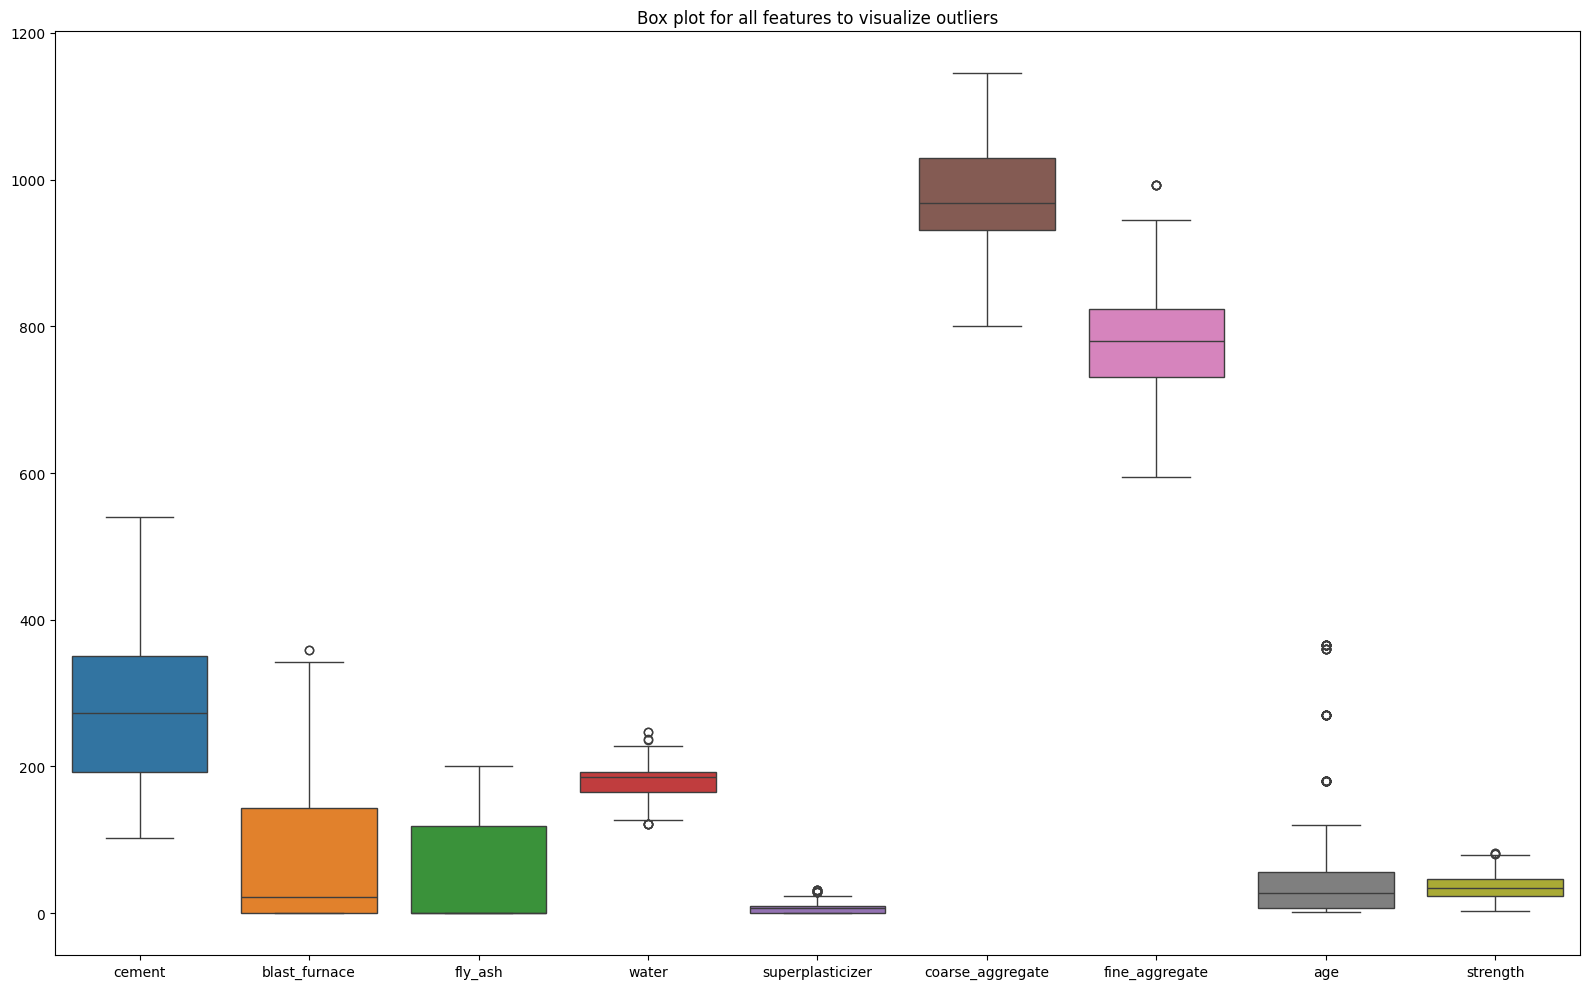

In [15]:
## check if data have outliers
# IQR, Boxplot

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(16,10))
sns.boxplot(data=df)
plt.title("Box plot for all features to visualize outliers")
plt.tight_layout()
plt.show()

In [28]:
outlier_summary = {}

for col in df.columns:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3-Q1
  lower_bound = Q1 - 1.5*IQR
  upper_bound = Q3 + 1.5*IQR
  outliers = df[(df[col]<lower_bound) | (df[col]>upper_bound)]
  outlier_summary[col] = len(outliers)
  print(f"{col} : {len(outliers)}")

cement : 0
blast_furnace : 2
fly_ash : 0
water : 9
superplasticizer : 10
coarse_aggregate : 0
fine_aggregate : 5
age : 59
strength : 4


In [ ]:
## Treatment of Outliers
'''
1. Leave them as it is - It may reflect real world variation
2. Remove outliers
3. Cap/Floor them
4. Use robust models which can handle outlier better -- XGBoost or any tree based model
'''

In [29]:
outlier_cols = [col for col in outlier_summary if outlier_summary[col]>0]
outlier_cols.remove('strength')
print(outlier_cols)

['blast_furnace', 'water', 'superplasticizer', 'fine_aggregate', 'age']


In [30]:
for col in outlier_cols:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3-Q1
  lower_bound = Q1 - 1.5*IQR
  upper_bound = Q3 + 1.5*IQR
  print(f"Rows before dropping outlier in column: {col} : {df.shape[0]}")
  df = df[(df[col]>=lower_bound) & (df[col]<=upper_bound)]
  print(f"Rows after dropping outlier in column: {col} : {df.shape[0]}")
  print("="*50)

Rows before dropping outlier in column: blast_furnace : 1030
Rows after dropping outlier in column: blast_furnace : 1028
Rows before dropping outlier in column: water : 1028
Rows after dropping outlier in column: water : 1019
Rows before dropping outlier in column: superplasticizer : 1019
Rows after dropping outlier in column: superplasticizer : 1009
Rows before dropping outlier in column: fine_aggregate : 1009
Rows after dropping outlier in column: fine_aggregate : 974
Rows before dropping outlier in column: age : 974
Rows after dropping outlier in column: age : 930


In [31]:
df.columns

Index(['cement', 'blast_furnace', 'fly_ash', 'water', 'superplasticizer',
       'coarse_aggregate', 'fine_aggregate', 'age', 'strength'],
      dtype='object')

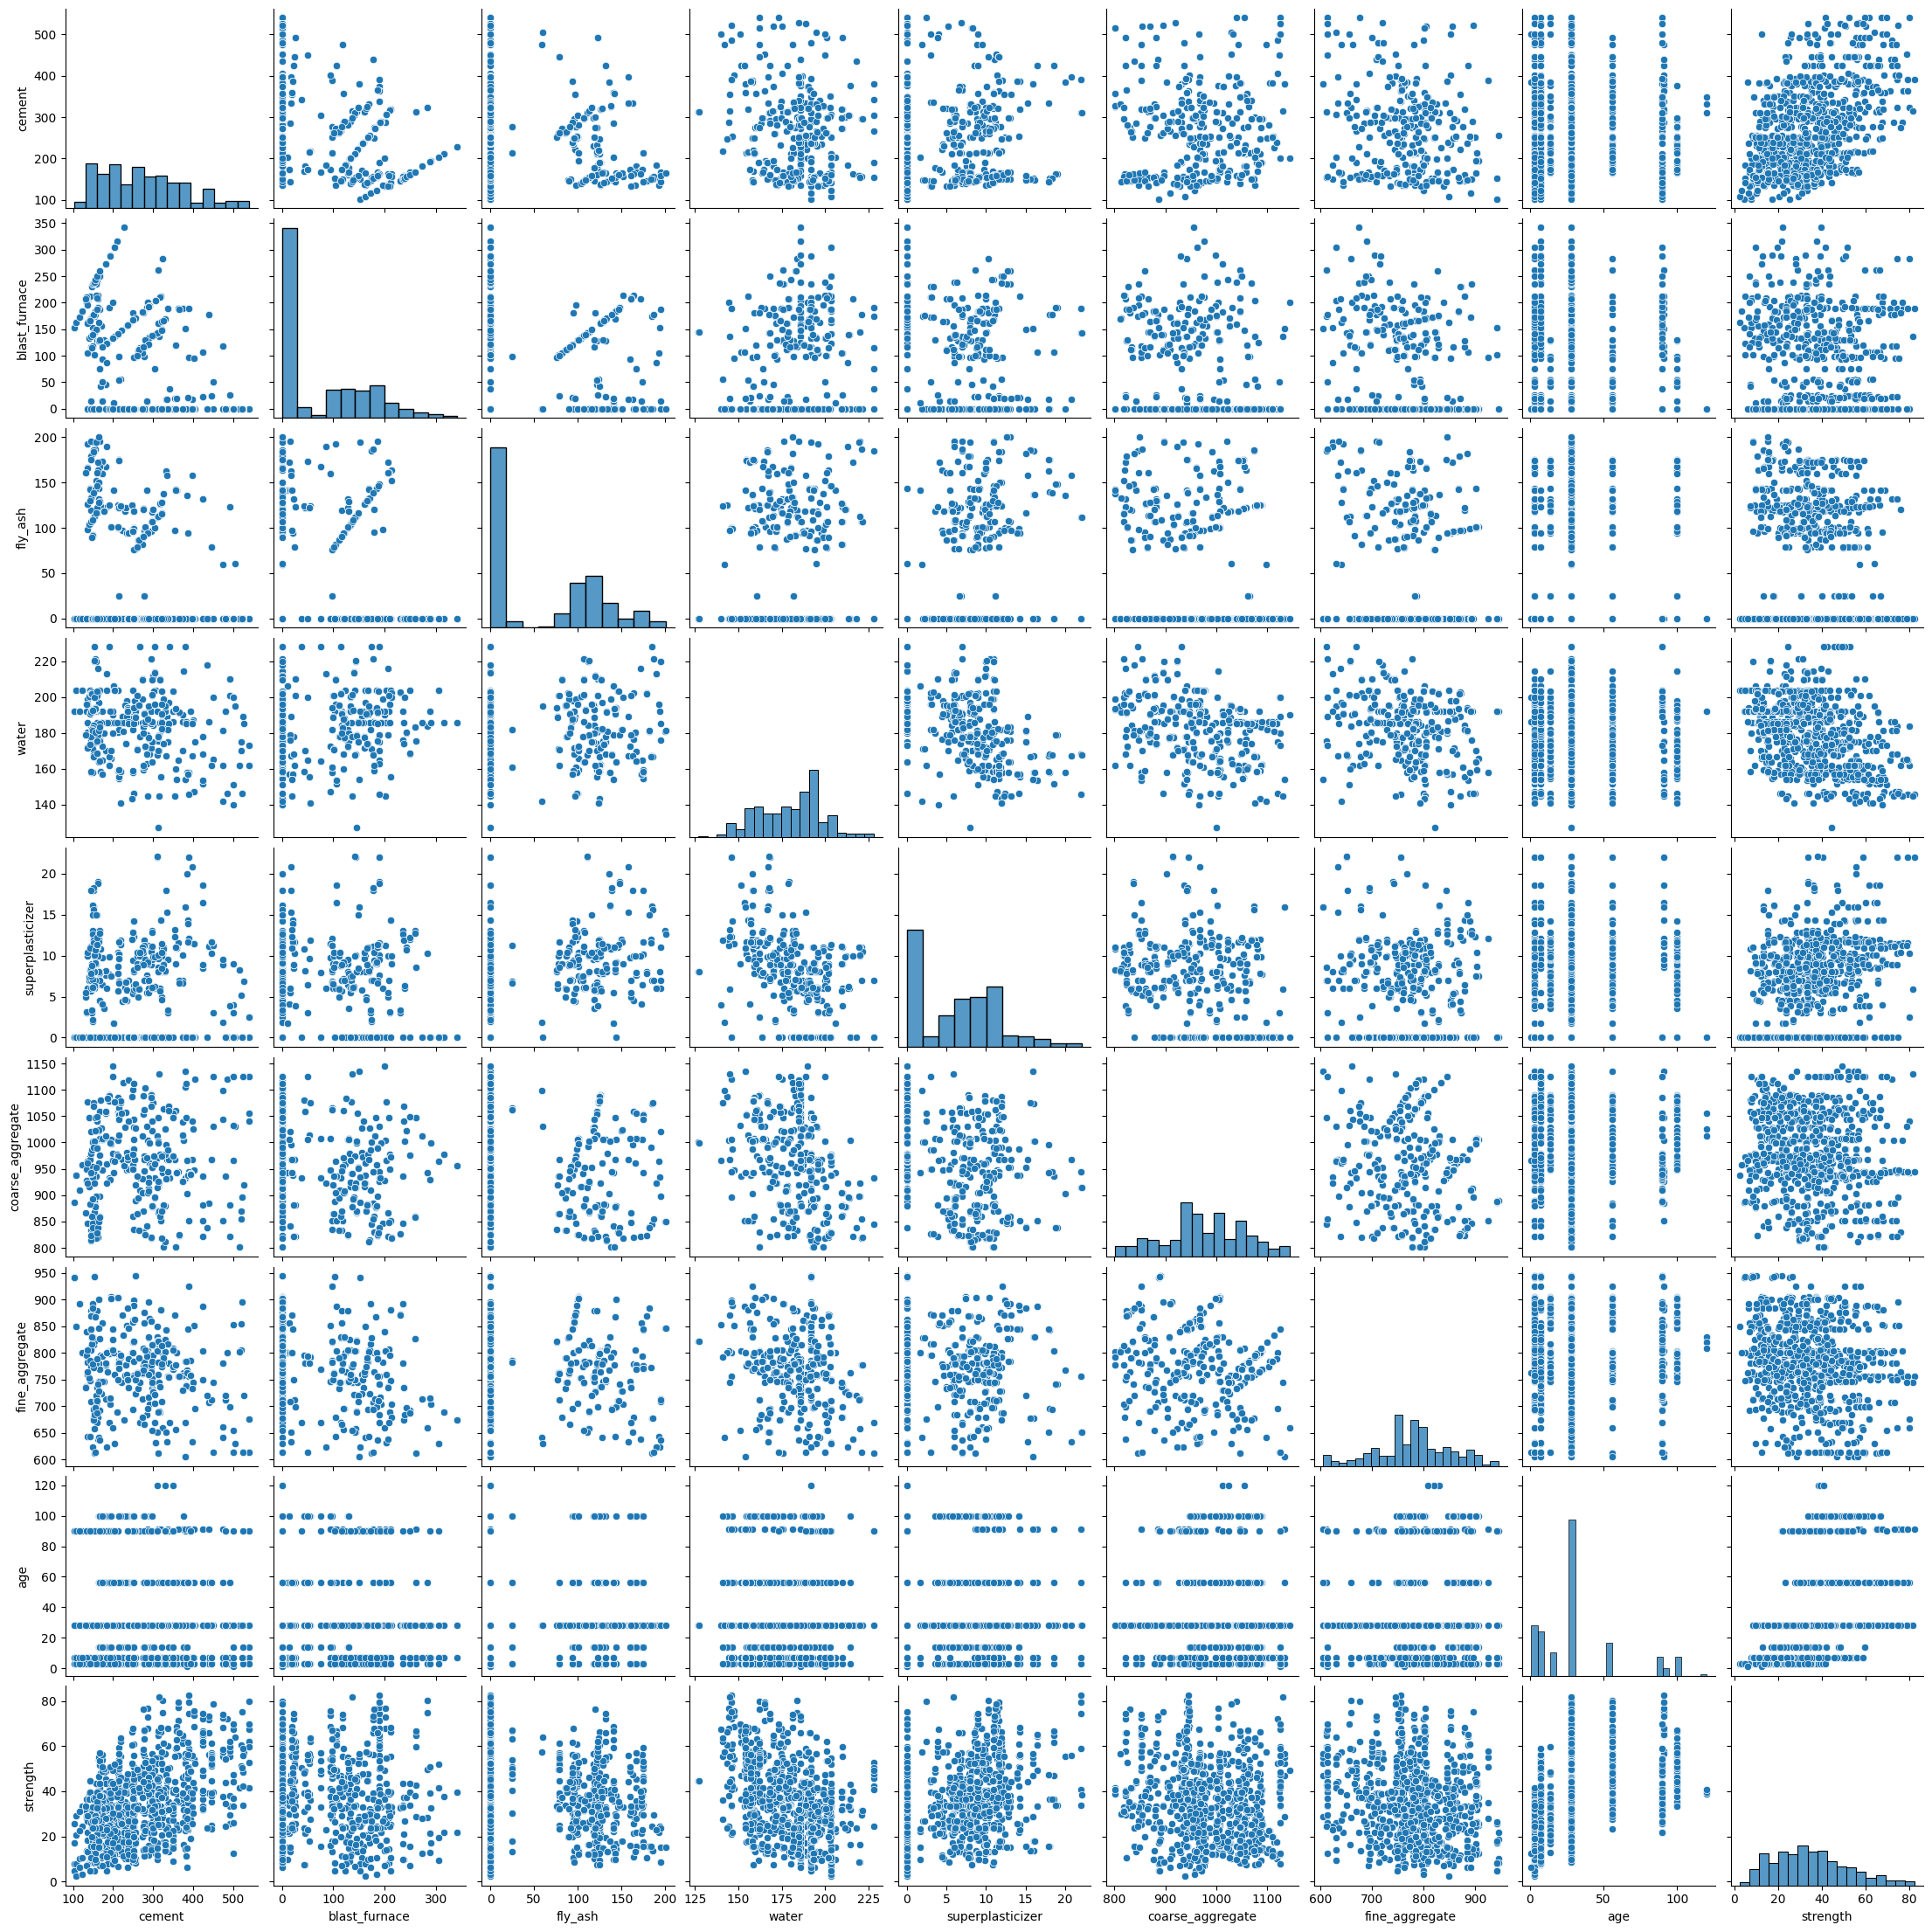

In [32]:
sns.pairplot(df[df.columns.tolist()])

In [33]:
df.columns

Index(['cement', 'blast_furnace', 'fly_ash', 'water', 'superplasticizer',
       'coarse_aggregate', 'fine_aggregate', 'age', 'strength'],
      dtype='object')

In [36]:
from sklearn.model_selection import train_test_split

In [ ]:
X = df.drop('strength',axis=1)
y = df['strength']

In [37]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape,y_train.shape

((744, 8), (744,))

In [38]:
X_test.shape

(186, 8)

In [44]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [49]:
## Train Regression models
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso, Ridge
lin = LinearRegression().fit(X_train_scaled,y_train)
ridge = Ridge(alpha=1.0).fit(X_train_scaled,y_train)
lasso = Lasso(alpha=0.1).fit(X_train_scaled,y_train)

In [42]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [59]:
y_pred = lin.predict(X_test_scaled)
mse = mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)
print(f"LinearRegression: MSE: {mse}, R2: {r2}")

y_pred = ridge.predict(X_test_scaled)
mse = mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)
print(f"RidgeRegression: MSE: {mse}, R2: {r2}")

y_pred = lasso.predict(X_test_scaled)
mse = mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)
print(f"LassoRegression: MSE: {mse}, R2: {r2}")

LinearRegression: MSE: 461.3523449234687, R2: -0.7026502269964194
RidgeRegression: MSE: 460.390142288806, R2: -0.6990991568602165
LassoRegression: MSE: 455.0176494240195, R2: -0.6792716295995003


In [67]:
y_test.reset_index(drop=True,inplace=True)
y_test.index

RangeIndex(start=0, stop=186, step=1)

In [69]:
y_test = y_test[:10]
y_pred = y_pred[:10]

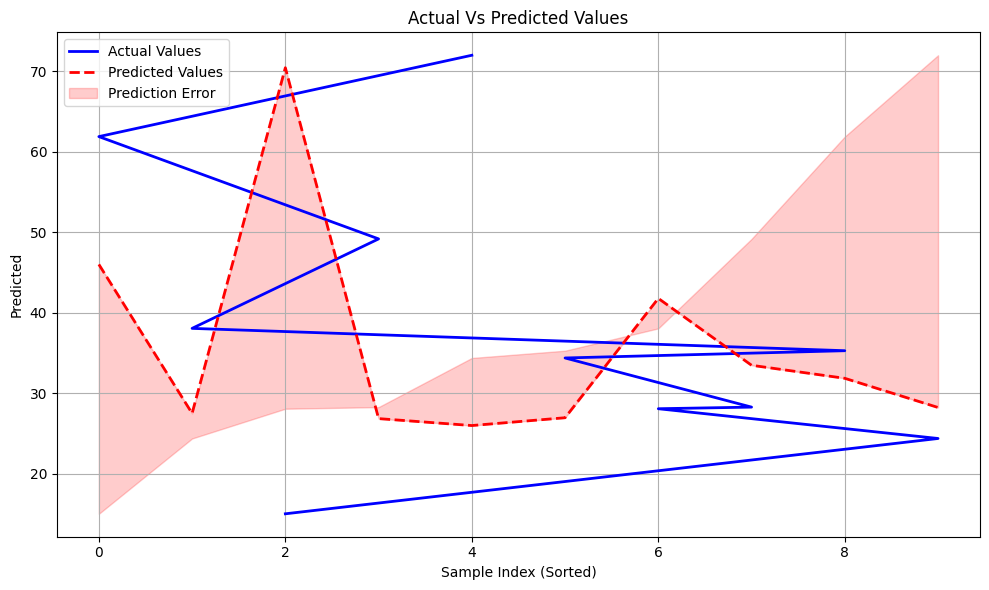

In [70]:
indices=np.argsort(y_test)
y_test_sorted = y_test[indices]
y_pred_sorted = y_pred[indices]
plt.figure(figsize=(10,6))
plt.plot(y_test_sorted,label='Actual Values',color='blue',linewidth=2)
plt.plot(y_pred_sorted,label='Predicted Values',color='red',linestyle='--',linewidth=2)

errors = y_pred_sorted - y_test_sorted
plt.fill_between(range(len(y_test_sorted)), y_test_sorted,y_pred_sorted,
                 color='red',alpha = 0.2, label = 'Prediction Error')
plt.title("Actual Vs Predicted Values")
plt.xlabel("Sample Index (Sorted)")
plt.ylabel("Predicted")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

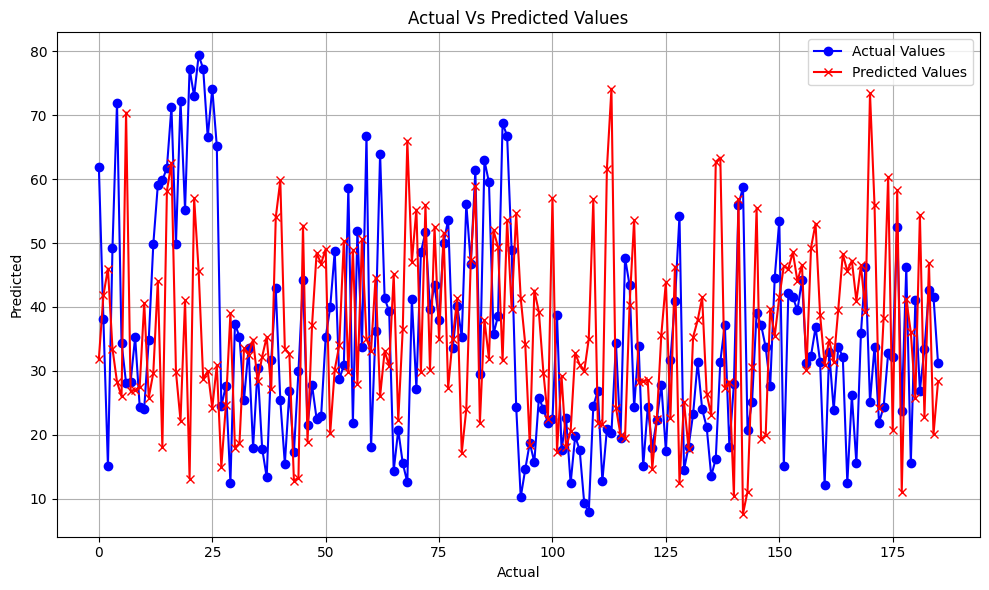

In [61]:
plt.figure(figsize=(10,6))
plt.plot(y_test.values,label='Actual Values',color='blue',marker='o')
plt.plot(y_pred,label='Predicted Values',color='red',marker='x')

plt.title("Actual Vs Predicted Values")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'LinearRegression Model')

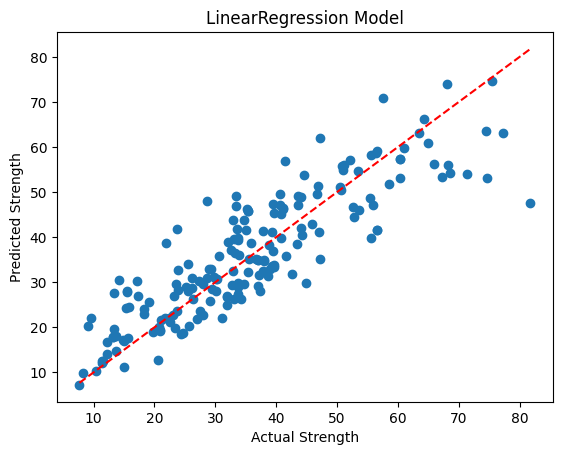

In [48]:
plt.scatter(y_test,y_pred)
plt.plot([y_test.min(),y_test.max()], [y_test.min(),y_test.max()], 'r--')
plt.xlabel("Actual Strength")
plt.ylabel("Predicted Strength")
plt.title("LinearRegression Model")

In [51]:
from sklearn.metrics import root_mean_squared_error

In [72]:
## K-Fold Cross validation
# F1,F2,F3,F4,F5
#                     TRAIN             TEST
# 1st time train --   [F1,F2,F3,F4]       F5
# 2nd time train --   [F1,F2,F3,F5]       F4
# 3rd time train --   [F1,F2,F4,F5]       F3
# 4th time train --   [F1,F3,F4,F5]       F2
# 5th time train --   [F2,F3,F4,F5]       F1



from sklearn.model_selection import KFold

kf = KFold(n_splits=5,shuffle=True,random_state=42)

mse_list = []
rmse_list = []
model = LinearRegression()
for train_index, test_index in kf.split(X):
  X_train,X_test = X.iloc[train_index],X.iloc[test_index]
  y_train,y_test = y.iloc[train_index],y.iloc[test_index]
  # model = LinearRegression()
  model.fit(X_train,y_train)
  y_pred = model.predict(X_test)
  mse = mean_squared_error(y_test,y_pred)
  rmse = root_mean_squared_error(y_test,y_pred)
  mse_list.append(mse)
  rmse_list.append(rmse)

In [77]:
pd.DataFrame({"Actual Values":y_test.values,"Predicted Values":y_pred})

,Actual Values,Predicted Values
0,61.887366,57.219041
1,38.074244,42.292298
2,15.049193,19.088315
3,49.185149,41.943197
4,71.988189,52.670465
...,...,...
181,26.922659,26.382532
182,33.399596,31.615887
183,42.644091,31.707787
184,41.542308,34.035192


In [75]:
y_pred

array([57.2190405 , 42.29229769, 19.0883149 , 41.94319727, 52.67046463,
       45.89755843, 42.62037431, 45.27247917, 46.21076487, 43.39624105,
       40.56448864, 43.90086603, 46.5529709 , 57.34024856, 52.0898554 ,
       58.72400762, 54.21383816, 48.56756193, 65.17504472, 59.58688969,
       63.17728025, 60.36275643, 73.02627221, 63.17728025, 72.2576001 ,
       76.37934733, 77.74401462, 15.82175152, 28.51870614, 15.71364141,
       46.76556579, 34.93018682, 16.96921488, 44.49978701, 17.96175874,
       21.48311099, 21.43908535, 13.61941021, 27.4978182 , 50.54666929,
       23.34831495, 19.31432261, 22.83567486, 17.63563358, 21.15698583,
       48.7875837 , 21.20146713, 25.68318817, 26.07210847, 25.70333379,
       29.22468604, 33.70640708, 42.66984917, 28.172708  , 32.65442904,
       59.36340685, 26.82317822, 43.7896936 , 29.44844633, 48.02278815,
       27.84426551, 33.77321569, 47.73543173, 57.45128489, 30.62252291,
       13.99528749, 22.31516461, 24.21563864, 17.26177613, 31.69

In [74]:
# indices=np.argsort(y_test)
# y_test_sorted = y_test[indices]
# y_pred_sorted = y_pred[indices]
# plt.figure(figsize=(10,6))
# plt.plot(y_test_sorted,label='Actual Values',color='blue',linewidth=2)
# plt.plot(y_pred_sorted,label='Predicted Values',color='red',linestyle='--',linewidth=2)

# errors = y_pred_sorted - y_test_sorted
# plt.fill_between(range(len(y_test_sorted)), y_test_sorted,y_pred_sorted,
#                  color='red',alpha = 0.2, label = 'Prediction Error')
# plt.title("Actual Vs Predicted Values")
# plt.xlabel("Sample Index (Sorted)")
# plt.ylabel("Predicted")
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.show()

In [54]:
import numpy as np

In [58]:
rmse_list

[7.839194798119997,
 8.91628974173454,
 8.663821808831283,
 7.582113279450805,
 7.585816846197559]

In [57]:
mse_list

[61.45297508287162,
 79.5002227585606,
 75.06180833518057,
 57.488441782424246,
 57.544617224054676]

In [56]:
np.mean(mse_list),np.mean(rmse_list)

(np.float64(66.20961303661832), np.float64(8.117447294866837))

In [ ]:
'''
What if model is not working properly - It means error is high

0. Are features really capable to predict ?? -- Domain knowledge ..

1. Can we increase training data points ?
2. Try more complex model -- Non Linear model .. Polynomial model , NN, Tree based model (robust to outliers)

'''